In [6]:
import re
import matplotlib.pyplot as plt
import numpy as np

In [11]:
# Sample config text
config_text = """
INFO     -   65   -     MultiMAE     - 2024-02-04 12:12:39,219 - run debug-only-semseg_2024-02-04_12:12:35 started
WARNING  -   65   -     MultiMAE     - 2024-02-04 12:12:39,221 - `iters_per_epoch` was not passed to the constructor. Defaulting to the length of the dataloader.
INFO     -   65   -     MultiMAE     - 2024-02-04 12:12:39,221 - Epoch 0001: train started
INFO     -   65   -     MultiMAE     - 2024-02-04 14:03:20,022 - Epoch 0001: avg train loss = 1585
INFO     -   65   -     MultiMAE     - 2024-02-04 14:03:20,022 - Epoch 0001: train finished
INFO     -   65   -     MultiMAE     - 2024-02-04 14:03:20,033 - Epoch 0001: validation started
INFO     -   65   -     MultiMAE     - 2024-02-04 14:12:02,099 - Epoch 0001: validation metrics: {'rmse': 795.7082681776602, 'rel': 0.025815852057141594, 'srel': 27.80106708671473, 'log10': 0.03658892454791673, 'delta_1': 0.999663034571877, 'delta_2': 0.999980092048645, 'delta_3': 1.0}
INFO     -   65   -     MultiMAE     - 2024-02-04 14:12:02,100 - Epoch 0001: validation finished
INFO     -   65   -     MultiMAE     - 2024-02-04 14:12:02,101 - Epoch: 1; metrics on val: {'rmse': 795.7082681776602, 'rel': 0.025815852057141594, 'srel': 27.80106708671473, 'log10': 0.03658892454791673, 'delta_1': 0.999663034571877, 'delta_2': 0.999980092048645, 'delta_3': 1.0}
INFO     -   65   -     MultiMAE     - 2024-02-04 14:12:03,731 - Epoch 0002:
"""
# Extracting loss values
train_loss_pattern = r"Epoch (\d{4}): avg train loss = (\d+)"
val_loss_pattern = r"Epoch: (\d+); metrics on val: {'rmse': ([\d.]+)"

In [14]:
with open('/home/MultiModalCoreset/multimae/zh_logs/logs/rgb-zhores-0_2024-02-22_18:50:47.log', 'r') as f:
    rgb_text = ''.join(f.readlines())

with open('/home/MultiModalCoreset/multimae/zh_logs/logs/semseg-zhores-0_2024-02-23_14:53:58.log', 'r') as f:
    semseg_text = ''.join(f.readlines())

with open('/home/MultiModalCoreset/multimae/zh_logs/logs/rgb-semseg-zhores-0_2024-02-24_00:47:45.log', 'r') as f:
    multi_text = ''.join(f.readlines())

In [17]:
# Find all matches
train_losses_rgb = re.findall(train_loss_pattern, rgb_text)
val_losses_rgb = re.findall(val_loss_pattern, rgb_text)

train_losses_semseg = re.findall(train_loss_pattern, semseg_text)
val_losses_semseg = re.findall(val_loss_pattern, semseg_text)

train_losses_multi = re.findall(train_loss_pattern, multi_text)
val_losses_multi = re.findall(val_loss_pattern, multi_text)

# Convert to numeric and separate epochs and losses
epochs_train, losses_train_rgb = zip(*[(int(epoch), float(loss)) for epoch, loss in train_losses_rgb])
epochs_val, losses_val_rgb = zip(*[(int(epoch), float(loss)) for epoch, loss in val_losses_rgb])

epochs_train, losses_train_semseg = zip(*[(int(epoch), float(loss)) for epoch, loss in train_losses_semseg])
epochs_val, losses_val_semseg = zip(*[(int(epoch), float(loss)) for epoch, loss in val_losses_semseg])

epochs_train, losses_train_multi = zip(*[(int(epoch), float(loss)) for epoch, loss in train_losses_multi])
epochs_val, losses_val_multi = zip(*[(int(epoch), float(loss)) for epoch, loss in val_losses_multi])

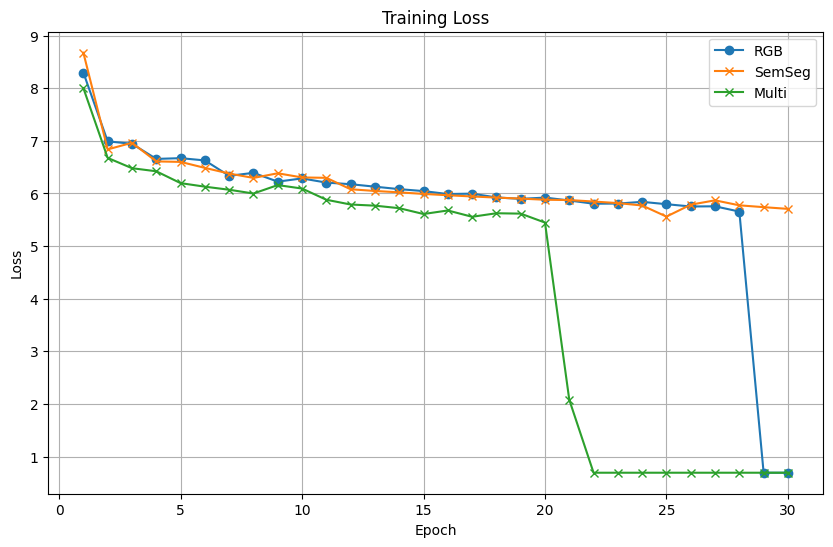

In [24]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_train, np.log(losses_train_rgb), label='RGB', marker='o')
plt.plot(epochs_train, np.log(losses_train_semseg), label='SemSeg', marker='x')
plt.plot(epochs_train, np.log(losses_train_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

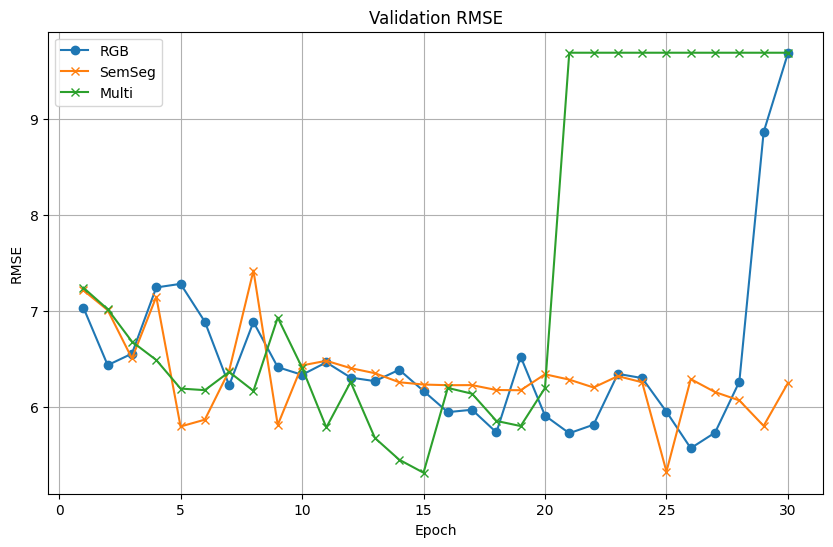

In [20]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_val, np.log(losses_val_rgb), label='RGB', marker='o')
plt.plot(epochs_val, np.log(losses_val_semseg), label='SemSeg', marker='x')
plt.plot(epochs_val, np.log(losses_val_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Validation RMSE')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
np.min(losses_val_rgb), np.min(losses_val_semseg), np.min(losses_val_multi)

(263.811572265625, 206.81939544677735, 204.46053314208984)